# Дифференцирование

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axhline.html#matplotlib.pyplot.axhline
* https://numpy.org/doc/stable/reference/generated/numpy.log1p.html#numpy.log1p
* https://docs.sympy.org/latest/tutorials/intro-tutorial/calculus.html
* https://en.wikipedia.org/wiki/Finite_difference
* https://pythonnumericalmethods.berkeley.edu/notebooks/chapter20.02-Finite-Difference-Approximating-Derivatives.html
* https://en.wikipedia.org/wiki/Gradient_descent
* https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html
* https://zhang-yang.medium.com/the-gradient-argument-in-pytorchs-backward-function-explained-by-examples-68f266950c29

## Задачи для совместного разбора

1\. Дана функция $f(x) = x^2$. Найдите производную этой функции различными способами

In [ ]:
import torch

In [ ]:
x = torch.tensor(2.0, requires_grad=True)
f = x**2
f.backward()
x.grad


tensor(4.)

In [ ]:
from sympy import symbols, diff
x = symbols('x')
f = x**2
diff(f, x)

2*x

In [ ]:
import numpy as np

def f(x):
    return x**2

x = 2.0
h = 0.0001  # приращение

answer = (f(x + h) - f(x)) / h
answer

4.0001000000078335

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Дана функция $f(x)$. Найдите (аналитически) производную данной функции $f'(x)$ и реализуйте две этих функции. Постройте в одной системе координат графики $f(x)$, $f'(x)$ и $g(x) = 0$ на отрезке [1, 10]. Изобразите графики различными цветами и включите сетку.

$$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

- [ ] Проверено на семинаре

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def f(x):
    return np.sin(x) / (np.log(x) + 1)

def f_prime(x):
    return (np.cos(x) * (np.log(x) + 1) - np.sin(x) / x) / (np.log(x) + 1)**2

def g(x):
    return np.zeros_like(x)

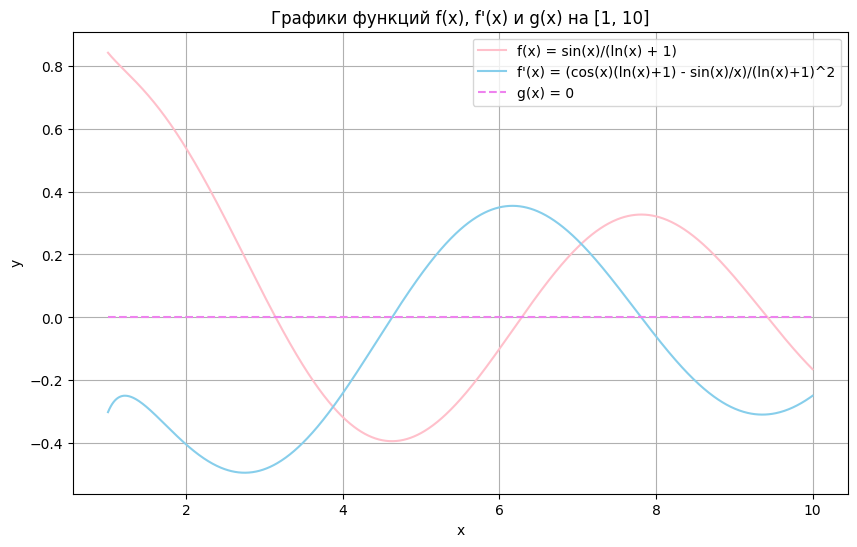

In [ ]:
x = np.linspace(1, 10, 1000)

y_f = f(x)
y_f_prime = f_prime(x)
y_g = g(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y_f, label='f(x) = sin(x)/(ln(x) + 1)', color='pink')
plt.plot(x, y_f_prime, label="f'(x) = (cos(x)(ln(x)+1) - sin(x)/x)/(ln(x)+1)^2", color='skyblue')
plt.plot(x, y_g, label='g(x) = 0', color='violet', linestyle='--')
plt.grid(True)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Графики функций f(x), f\'(x) и g(x) на [1, 10]')
plt.legend()

plt.show()

<p class="task" id="2"></p>

2\. Дана функция $f(x)$. Найдите (численно) производную данной функции $f'(x)$ на отрезке [1, 10]. Постройте в одной системе координат график $f(x)$, $f'(x)$ и $g(x) = 0$. Изобразите графики различными цветами и включите сетку.

$$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

- [ ] Проверено на семинаре

In [ ]:
def f(x):
    return np.sin(x) / (np.log(x) + 1)

# центральная разность
def f_prime_num(x, h=1e-4):
    return (f(x + h) - f(x - h)) / (2 * h)

def g(x):
    return np.zeros_like(x)

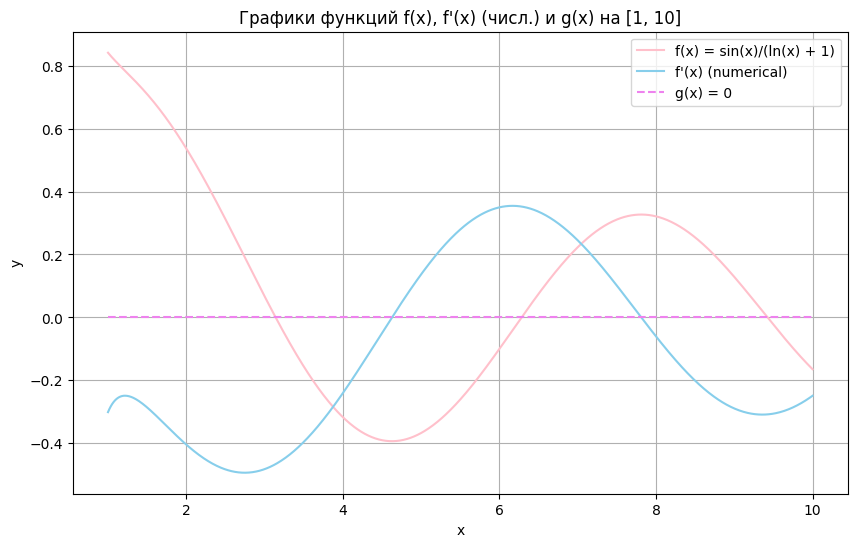

In [ ]:
x = np.linspace(1, 10, 1000)

y_f = f(x)
y_f_prime = f_prime_num(x)
y_g = g(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y_f, label='f(x) = sin(x)/(ln(x) + 1)', color='pink')
plt.plot(x, y_f_prime, label="f'(x) (numerical)", color='skyblue')
plt.plot(x, y_g, label='g(x) = 0', color='violet', linestyle='--')

plt.grid(True)

plt.xlabel('x')
plt.ylabel('y')
plt.title("Графики функций f(x), f'(x) (числ.) и g(x) на [1, 10]")
plt.legend()

plt.show()

<p class="task" id="3"></p>

3\. Найдите локальный минимум функции $f(x)$ при помощи метода градиентного спуска. В качестве начальной точки используйте $x_0 = 4$. Найдите локальный максимум этой же функции, используя в качестве начальной точки $x_0'=9$.

$$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

- [ ] Проверено на семинаре

In [ ]:
def f_prime(x):
    return (np.cos(x) * (np.log(x) + 1) - np.sin(x) / x) / (np.log(x) + 1)**2

def find_minimum(x0, learning_rate=0.01, iter=1000, tol=1e-6):
    x = x0
    path = [x]

    for _ in range(iter):
        grad = f_prime(x)
        x_new = x - learning_rate * grad
        x_new = np.clip(x_new, 1, 10)
        # проверяем сходимость
        if np.abs(x_new - x) < tol:
            break
        x = x_new
        path.append(x)

    return x, f(x), path

def find_maximum(x0, learning_rate=0.01, iter=1000, tol=1e-6):
    x = x0
    path = [x]

    for _ in range(iter):
        grad = f_prime(x)
        x_new = x + learning_rate * grad
        x_new = np.clip(x_new, 1, 10)
        if np.abs(x_new - x) < tol:
            break
        x = x_new
        path.append(x)

    return x, f(x), path

In [ ]:
x0_min = 4.0
x0_max = 9.0
learning_rate = 0.01
iter = 1000
tol = 1e-6

min_x, min_y, min_path = find_minimum(x0_min, learning_rate, iter, tol)
max_x, max_y, max_path = find_maximum(x0_max, learning_rate, iter, tol)

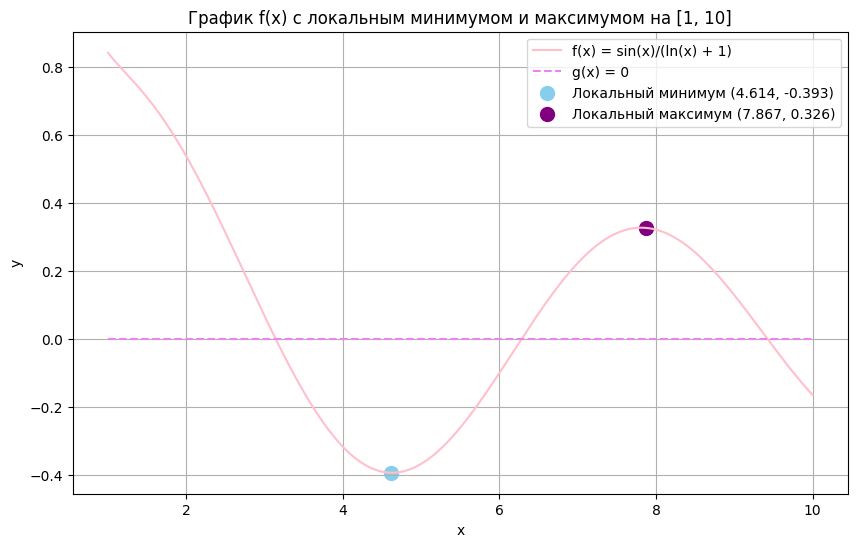

Локальный минимум: x = 4.614, f(x) = -0.393
Локальный максимум: x = 7.867, f(x) = 0.326


In [ ]:
x_np = np.linspace(1, 10, 1000)
y_np = f(x_np)
y_g = np.zeros_like(x_np)

plt.figure(figsize=(10, 6))
plt.plot(x_np, y_np, label='f(x) = sin(x)/(ln(x) + 1)', color='pink')
plt.plot(x_np, y_g, label='g(x) = 0', color='violet', linestyle='--')
plt.scatter([min_x], [min_y], color='skyblue', s=100, label=f'Локальный минимум ({min_x:.3f}, {min_y:.3f})')
plt.scatter([max_x], [max_y], color='purple', s=100, label=f'Локальный максимум ({max_x:.3f}, {max_y:.3f})')

plt.grid(True)

plt.xlabel('x')
plt.ylabel('y')
plt.title('График f(x) с локальным минимумом и максимумом на [1, 10]')
plt.legend()

plt.show()

print(f"Локальный минимум: x = {min_x:.3f}, f(x) = {min_y:.3f}")
print(f"Локальный максимум: x = {max_x:.3f}, f(x) = {max_y:.3f}")

<p class="task" id="4"></p>

4\. Дана функция $f(x)$. Найдите (используя возможности по автоматическому дифференцированию пакета `torch`) производную данной функции $f'(x)$ на отрезке [0, 10]. Постройте в одной системе координат график $f(x)$, $f'(x)$ и $g(x) = 0$ на полуинтервале (0, 10]. Изобразите графики различными цветами и включите сетку.

$$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

- [ ] Проверено на семинаре

In [ ]:
def f(x):
    return torch.sin(x) / (torch.log(x) + 1)

In [ ]:
x = torch.linspace(1, 10, 1000, requires_grad=True)
y_f = f(x)
#суммирую y_f для получения скаляра, чтобы найти градиент
y_df = torch.autograd.grad(y_f.sum(), x, create_graph=False)[0]

In [ ]:
x_np = x.detach().numpy()
y_f_np = y_f.detach().numpy()
y_df_np = y_df.detach().numpy()

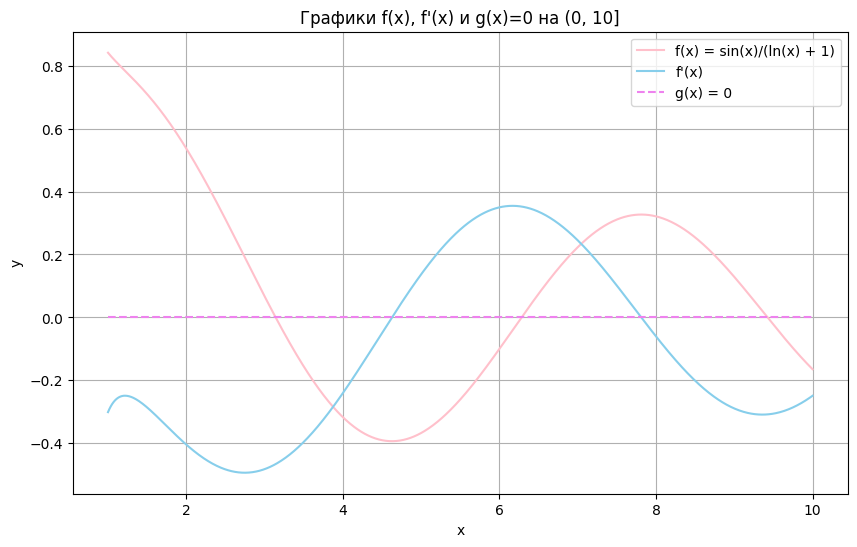

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(x_np, y_f_np, label='f(x) = sin(x)/(ln(x) + 1)', color='pink')
plt.plot(x_np, y_df_np, label="f'(x)", color='skyblue')
plt.plot(x_np, np.zeros_like(x_np), label='g(x) = 0', color='violet', linestyle='--')
plt.grid(True)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Графики f(x), f\'(x) и g(x)=0 на (0, 10]')
plt.legend()
plt.show()

<p class="task" id="5"></p>

5\. Дана функция $f(x)$. Найдите производную данной функции $f'(x)$ на отрезке [0, 10] при помощи формулы производной сложной функции. На этом же отрезке найдите, используя возможности по автоматическому дифференцированию пакета `torch`. Сравните результаты.

$$f(x) = sin(cos(x))$$

- [ ] Проверено на семинаре

In [ ]:
def g(x: torch.Tensor) -> torch.Tensor:
    return torch.cos(x)

def h(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(x)

def dfdg(x: torch.Tensor) -> torch.Tensor:
    return torch.cos(g(x))

def dgdx(x: torch.Tensor) -> torch.Tensor:
    return -torch.sin(x)

def dfdx(x: torch.Tensor) -> torch.Tensor:
    return dfdg(x)*dgdx(x)

In [ ]:
x = torch.linspace(0, 10, 1000, requires_grad = True)

y_f = h(g(x))
y_autograd = torch.autograd.grad(y_f.sum(), x, create_graph = False)[0]

y_df = dfdx(x)

In [ ]:
x_np = x.detach().numpy()
y_f_np = y_f.detach().numpy()
y_autograd_np = y_autograd.detach().numpy()
y_df_np = y_df.detach().numpy()

In [ ]:
plt.figure(figsize=(12, 7))
plt.plot(x_np, y_f_np, label='f(x) = sin(cos(x))', color='blue', linewidth=2)
plt.plot(x_np, y_df_autograd_np, label="f'(x) (autograd)", color='red', linewidth=2)
plt.plot(x_np, y_df_analytic_np, label="f'(x) (analytic)", color='green', linewidth=2)
plt.axhline(0.0, ls='--', lw=1.5, color='black', label='g(x)=0')
plt.xlim(0, 10)
plt.ylim(-1.5, 1.5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title("f(x), f'(x) (autograd и аналитически) на [0, 10]", fontsize=14)
plt.legend(fontsize=10)
plt.show()